In [ ]:
!pip install -q tensorflow scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("TF version:", tf.__version__)
from google.colab import files
uploaded = files.upload()  
csv_filename = list(uploaded.keys())[0]
print("Loaded:", csv_filename)

df = pd.read_csv(csv_filename)
if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])
df = df.select_dtypes(include=[np.number]).copy()
print("Using features:", df.columns.tolist())
n_samples, n_features = df.shape
print("Shape:", df.shape)

df = df.interpolate().fillna(method='bfill').fillna(method='ffill')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)  

def create_windows(X, seq_len=100, step=1):
    n_samples, n_features = X.shape
    windows = []
    starts = []
    for start in range(0, n_samples - seq_len + 1, step):
        windows.append(X[start:start+seq_len])
        starts.append(start)
    return np.stack(windows), np.array(starts)

SEQ_LEN = 100 
STEP = 1
X_windows, window_starts = create_windows(X_scaled, seq_len=SEQ_LEN, step=STEP)
print("Windows shape:", X_windows.shape)  

train_windows, val_windows = train_test_split(X_windows, test_size=0.10, random_state=42)
print("Train windows:", train_windows.shape, "Val windows:", val_windows.shape)

tf.keras.backend.clear_session()
n_features = X_windows.shape[2]
input_shape = (SEQ_LEN, n_features)
inputs = layers.Input(shape=input_shape)

# --- Encoder (Conv1D blocks to reduce temporal resolution + feature extraction)
x = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(pool_size=2, padding='same')(x)   

x = layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(pool_size=2, padding='same')(x)  

x = layers.LSTM(64, return_sequences=False)(x)  
encoded = layers.Dense(32, activation='relu')(x) 

# --- Decoder
x = layers.RepeatVector(SEQ_LEN // 4 + (1 if (SEQ_LEN % 4) else 0))(encoded)  
x = layers.LSTM(64, return_sequences=True)(x)

x = layers.UpSampling1D(size=2)(x)   
x = layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x)

x = layers.UpSampling1D(size=2)(x)  
x = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(x)

decoded = layers.TimeDistributed(layers.Dense(n_features))(x)

autoencoder = models.Model(inputs, decoded)
autoencoder.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()


TF version: 2.19.0


Saving 0000.csv to 0000.csv
Loaded: 0000.csv
Using features: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES']
Shape: (32399, 11)


/tmp/ipython-input-1241702384.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate().fillna(method='bfill').fillna(method='ffill')


Windows shape: (32300, 100, 11)
Train windows: (29070, 100, 11) Val windows: (3230, 100, 11)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 25, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 11)        │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,579 (287.42 KB)

 Trainable params: 73,387 (286.67 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
EPOCHS = 50
BATCH_SIZE = 128
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
history = autoencoder.fit(
    train_windows, train_windows,
    validation_data=(val_windows, val_windows),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=2
)

Epoch 1/50
228/228 - 16s - 71ms/step - loss: 0.9265 - val_loss: 0.8820
Epoch 2/50
228/228 - 4s - 19ms/step - loss: 0.9113 - val_loss: 0.8679
Epoch 3/50
228/228 - 4s - 19ms/step - loss: 0.9022 - val_loss: 0.8720
Epoch 4/50
228/228 - 5s - 21ms/step - loss: 0.8992 - val_loss: 0.8659
Epoch 5/50
228/228 - 4s - 19ms/step - loss: 0.8956 - val_loss: 0.8560
Epoch 6/50
228/228 - 4s - 19ms/step - loss: 0.8907 - val_loss: 0.8483
Epoch 7/50
228/228 - 5s - 21ms/step - loss: 0.8880 - val_loss: 0.8521
Epoch 8/50
228/228 - 5s - 20ms/step - loss: 0.8833 - val_loss: 0.8474
Epoch 9/50
228/228 - 5s - 21ms/step - loss: 0.8917 - val_loss: 0.8466
Epoch 10/50
228/228 - 4s - 19ms/step - loss: 0.8857 - val_loss: 0.8420
Epoch 11/50
228/228 - 5s - 22ms/step - loss: 0.8766 - val_loss: 0.8341
Epoch 12/50
228/228 - 5s - 21ms/step - loss: 0.8738 - val_loss: 0.8326
Epoch 13/50
228/228 - 4s - 19ms/step - loss: 0.8758 - val_loss: 0.8559
Epoch 14/50
228/228 - 5s - 20ms/step - loss: 0.8680 - val_loss: 0.8259
Epoch 15/50
22

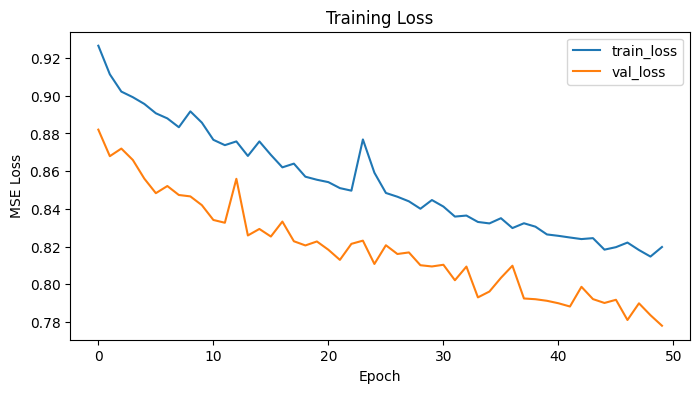

1010/1010 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step
MSE mean: 0.8053136387472235 std: 1.2383363594004293
threshold (mean+k*std): 4.520322716948511
threshold (percentile 98): 5.6084329039876675
Anomalous windows: 646  /  32300
Percent of samples flagged anomalous: 3.617%


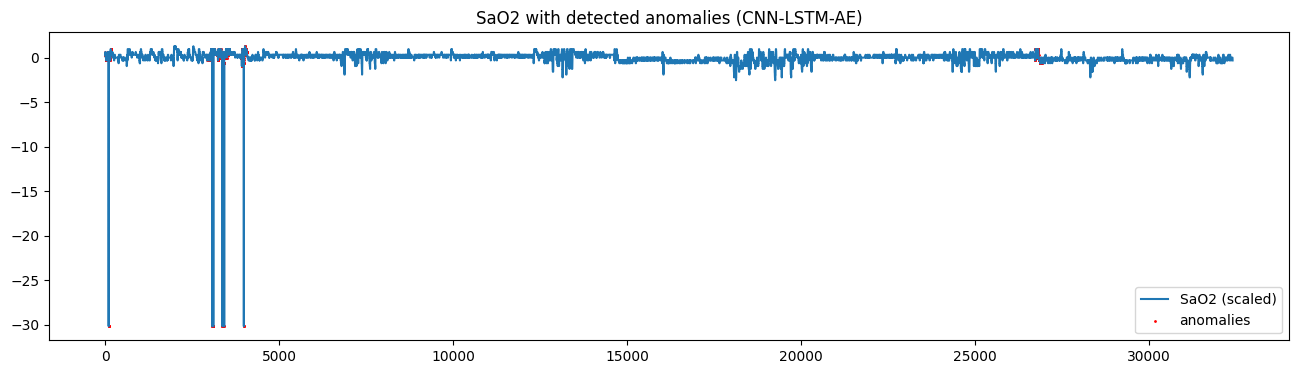

Rank 1: window_idx=3315, start_sample=3315, mse=14.312880
Rank 2: window_idx=3338, start_sample=3338, mse=13.157688
Rank 3: window_idx=3342, start_sample=3342, mse=12.591856
Rank 4: window_idx=26772, start_sample=26772, mse=12.059196
Rank 5: window_idx=26774, start_sample=26774, mse=12.057024
Rank 6: window_idx=26775, start_sample=26775, mse=12.047231
Rank 7: window_idx=26773, start_sample=26773, mse=12.046961
Rank 8: window_idx=26768, start_sample=26768, mse=12.022202
Rank 9: window_idx=26771, start_sample=26771, mse=12.006709
Rank 10: window_idx=26770, start_sample=26770, mse=12.005094


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved cnn_lstm_ae_anomalies_by_sample.csv


'\nfrom sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score\n\n# Suppose \'labels\' is an array of 0/1 values aligned to samples\nlabels = pd.read_csv(\'labels.csv\')[\'label\'].values  # adjust path/name\ny_true = labels.astype(int)\ny_pred = sample_anomaly.astype(int)\n\nprecision = precision_score(y_true, y_pred)\nrecall = recall_score(y_true, y_pred)\nf1 = f1_score(y_true, y_pred)\nprint("Precision:", precision, "Recall:", recall, "F1:", f1)\n\n# For ROC AUC use continuous window-level score mapped to samples (e.g., per-sample max window mse that includes sample)\n# Example mapping: per-sample score = max mse of windows covering that sample\nper_sample_score = np.zeros(n_samples)\nfor i in range(len(mse_per_window)):\n    s = window_starts[i]\n    per_sample_score[s:s+SEQ_LEN] = np.maximum(per_sample_score[s:s+SEQ_LEN], mse_per_window[i])\n\nroc_auc = roc_auc_score(y_true, per_sample_score)\nprint("ROC AUC:", roc_auc)\n'

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(); plt.title("Training Loss"); plt.show()

reconstructed = autoencoder.predict(X_windows)
mse_per_window = np.mean(np.square(reconstructed - X_windows), axis=(1,2))  # error per window

# threshold selection
# Option A: mean + k*std
k = 3.0
mu = mse_per_window.mean()
sigma = mse_per_window.std()
threshold_stat = mu + k * sigma

# Option B: percentile
percentile = 98
threshold_pct = np.percentile(mse_per_window, percentile)

print("MSE mean:", mu, "std:", sigma)
print("threshold (mean+k*std):", threshold_stat)
print(f"threshold (percentile {percentile}):", threshold_pct)

threshold = threshold_pct

anomaly_mask_windows = mse_per_window > threshold
print("Anomalous windows:", anomaly_mask_windows.sum(), " / ", len(anomaly_mask_windows))

n_samples = X_scaled.shape[0]
sample_anomaly = np.zeros(n_samples, dtype=bool)
for i, is_anom in enumerate(anomaly_mask_windows):
    if is_anom:
        s = window_starts[i]
        sample_anomaly[s:s+SEQ_LEN] = True

pct_samples_anom = sample_anomaly.sum() / n_samples * 100
print(f"Percent of samples flagged anomalous: {pct_samples_anom:.3f}%")

# Visualization of feature to plot (SaO2 index 0)
feature_idx = 0
feature_name = df.columns[feature_idx]
time = np.arange(n_samples)

plt.figure(figsize=(16,4))
plt.plot(time, X_scaled[:, feature_idx], label=f"{feature_name} (scaled)")
anom_idxs = np.where(sample_anomaly)[0]
plt.scatter(anom_idxs, X_scaled[anom_idxs, feature_idx], color='red', s=1, label='anomalies')
plt.legend(); plt.title(f"{feature_name} with detected anomalies (CNN-LSTM-AE)"); plt.show()

top_k = 10
top_idx = np.argsort(mse_per_window)[-top_k:][::-1]
for rank, idx in enumerate(top_idx, 1):
    start_sample = window_starts[idx]
    print(f"Rank {rank}: window_idx={idx}, start_sample={start_sample}, mse={mse_per_window[idx]:.6f}")

out_df = pd.DataFrame({
    'sample_index': np.arange(n_samples),
    **{col: df[col].values for col in df.columns},   
    'is_anomaly': sample_anomaly.astype(int)
})
out_df.to_csv("cnn_lstm_ae_anomalies_by_sample.csv", index=False)
from google.colab import files
files.download("cnn_lstm_ae_anomalies_by_sample.csv")
print("Saved cnn_lstm_ae_anomalies_by_sample.csv")

In [ ]:
autoencoder.save("cnn_lstm_autoencoder_model.keras")
autoencoder.save("cnn_lstm_autoencoder_model.h5")
print("Model saved successfully!")

✅ Model saved successfully!


In [ ]:
from google.colab import files
files.download("cnn_lstm_autoencoder_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>